In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['text.usetex'] = True

In [45]:
df = pd.read_csv('Ratio.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.783431
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.777522
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.825769
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.889904


In [46]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)

In [47]:
standard_scalar = StandardScaler()
X_train_transofrmed = standard_scalar.fit_transform(X_train)

/home/shantanurahman/micromamba/envs/ibeam-ml/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/shantanurahman/micromamba/envs/ibeam-ml/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/shantanurahman/micromamba/envs/ibeam-ml/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


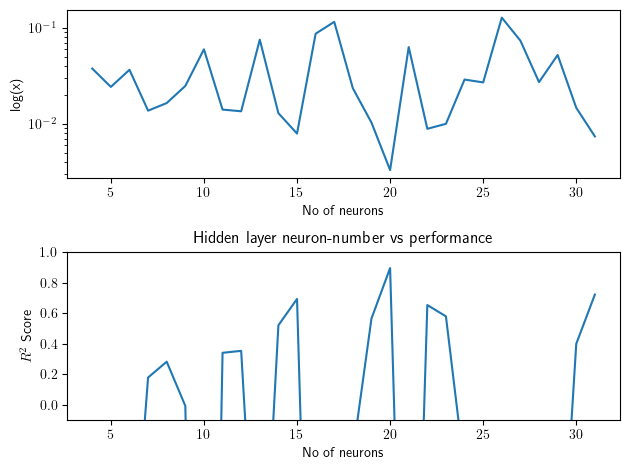

In [48]:
layersize = list(range(4, 32))
mselist = []
r2list = []

for x in layersize:
    mlp = MLPRegressor(hidden_layer_sizes=(x,x,x,x,x,x,x), random_state=100, early_stopping=True, max_iter=500)
    mlp.fit(X_train, y_train)

    y_predict = mlp.predict(X_full)

    mse_test = mean_squared_error(y_predict, y_full)
    r2_test = r2_score(y_predict, y_full)
    
    mselist.append(mse_test)
    r2list.append(r2_test)

plt.subplot(2, 1, 1)
plt.semilogy(layersize, mselist)
plt.ylabel("log(x)")
plt.xlabel("No of neurons")
plt.subplot(2, 1, 2)
plt.ylim([-0.1, 1])
plt.plot(layersize, r2list)
plt.ylabel(r"$R^2$ Score")
plt.xlabel(r"No of neurons")
plt.title("Hidden layer neuron-number vs performance")
plt.tight_layout()

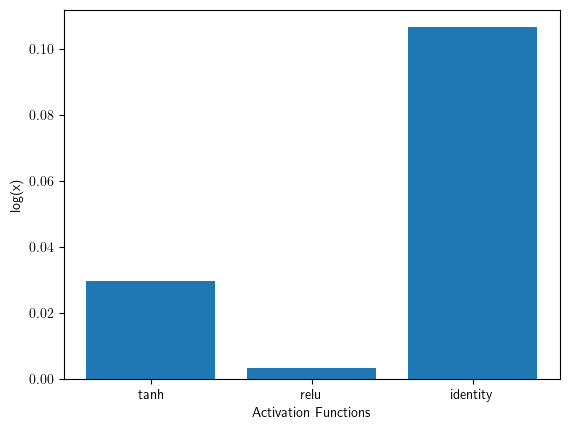

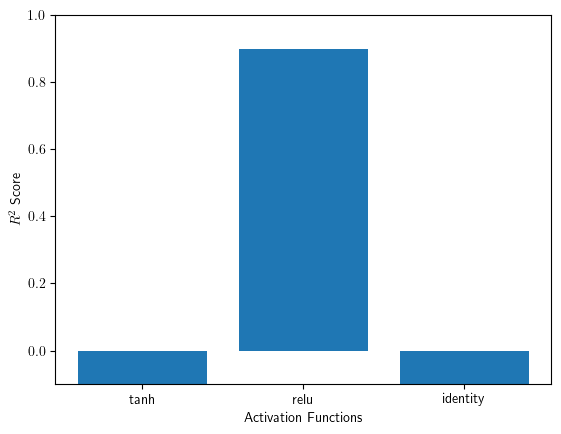

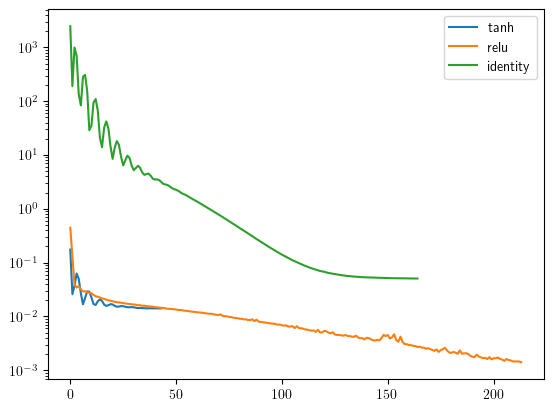

In [57]:
activations = ['tanh', 'relu', 'identity']
mselist = []
r2list = []
loss_curves = []

for af in activations:
    x = 20
    mlp = MLPRegressor(hidden_layer_sizes=(x,x,x,x,x,x,x), activation=af, random_state=100, early_stopping=True, max_iter=500)
    mlp.fit(X_train, y_train)

    y_predict = mlp.predict(X_full)

    loss_curves.append(mlp.loss_curve_)

    mse_test = mean_squared_error(y_predict, y_full)
    r2_test = r2_score(y_predict, y_full)
    
    mselist.append(mse_test)
    r2list.append(r2_test)

plt.bar(activations, mselist)
plt.ylabel("log(x)")
plt.xlabel("Activation Functions")
plt.show()

plt.ylim([-0.1, 1])
plt.bar(activations, r2list)
plt.ylabel(r"$R^2$ Score")
plt.xlabel(r"Activation Functions")
plt.show()

for af, loss in zip(activations, loss_curves):
    plt.semilogy(range(len(loss)), loss, label=af)
plt.legend()
plt.show()

In [ ]:
optimizers = ['
mselist = []
r2list = []
loss_curves = []

for af in activations:
    x = 20
    mlp = MLPRegressor(hidden_layer_sizes=(x,x,x,x,x,x,x), activation='relu', random_state=100, early_stopping=True, max_iter=500)
    mlp.fit(X_train, y_train)

    y_predict = mlp.predict(X_full)

    loss_curves.append(mlp.loss_curve_)

    mse_test = mean_squared_error(y_predict, y_full)
    r2_test = r2_score(y_predict, y_full)
    
    mselist.append(mse_test)
    r2list.append(r2_test)

plt.bar(activations, mselist)
plt.ylabel("log(x)")
plt.xlabel("Activation Functions")
plt.show()

plt.ylim([-0.1, 1])
plt.bar(activations, r2list)
plt.ylabel(r"$R^2$ Score")
plt.xlabel(r"Activation Functions")
plt.show()

for af, loss in zip(activations, loss_curves):
    plt.semilogy(range(len(loss)), loss, label=af)
plt.legend()
plt.show()